# M5 forecasting: top-down, bottom-up and middle-out

This notebook ports the three models of the [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit),
as already ported to [numpyro_forecast](https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html),
onto the PyMC forecasting classes. The competition panel is 30,490 daily unit-sales
series, a 28-day horizon, and 42,840 aggregates across 12 hierarchy levels.

The three models are three reconciliation strategies for that hierarchy:

- **Top-down.** One Student-T regression on the log of total daily sales, with a
  trend, weekday effects, and day-of-month effects. The forecast is exponentiated
  and split to the items by their share of the last 28 training days, then
  Poisson-sampled.
- **Bottom-up.** A Gamma regression for every series. Mean and scale weights are
  shared by the items of a department in a store: three lagged log moving
  averages, a SNAP flag, and a weekday effect, passed through a bounded
  exponential. Forecasts are already at the bottom of the hierarchy.
- **Middle-out.** A Student-T regression on the store-by-department series, each
  divided by its lag-1 scale, with a trend, weekday effects, and 52 yearly
  Fourier harmonics. Forecasts are clipped at zero, restored to units, and split
  inside each store-department.

Priors, covariates, the aggregation matrix, the dollar-share weights, the lag-1
scales, and the weighted scaled CRPS / pinball scores follow the kit. Two
deviations are deliberate:

- Inference is mean-field ADVI through `Forecaster`, not the kit's clipped,
  decaying, minibatch SVI. Posterior draws, and therefore scores, are not
  expected to match a NumPyro run. The contract tests lock the predictors and
  the scores against NumPy, not against a particular fit.
- The fits below use a hierarchy-preserving subset (one item from each
  department, in one store per state). The weight check still uses the full
  panel. CI sets `PYMC_FORECAST_SMOKE_TEST=1` and reruns the same notebook on
  a synthetic two-store panel. That run does not download the competition
  files; its scores are a smoke check, not a forecast.

In [1]:
import logging
import os
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_forecast import Forecaster
from pymc_forecast.data import TIME_DIM
from pymc_forecast.datasets import M5Data, load_m5
from pymc_forecast.m5 import (
    GAMMA_FLOOR,
    HORIZON,
    LEVELS,
    N_DAYS,
    N_DAYS_TRAIN,
    T0,
    BottomUpModel,
    MiddleOutModel,
    TopDownModel,
    aggregate,
    bottom_covariates,
    build_aggregation,
    forecast_draws,
    level_panel,
    log_total,
    m5_scales,
    m5_weights,
    mean_level_score,
    middle_covariates,
    reconcile_middle_out,
    reconcile_top_down,
    score_bottom,
    select_series,
    top_covariates,
    weight_gap,
)

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

SMOKE = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
SEED = 2026
STORES = ["CA_1", "TX_1"] if SMOKE else ["CA_1", "TX_1", "WI_1"]
ORIGIN = (T0 + HORIZON) if SMOKE else N_DAYS_TRAIN
STEPS = (
    {"top-down": 40, "bottom-up": 40, "middle-out": 40}
    if SMOKE
    else {"top-down": 20_000, "bottom-up": 80_000, "middle-out": 20_000}
)
SAMPLES = 20 if SMOKE else 200
print(
    "Execution mode:",
    "CI smoke check; do not interpret fit quality" if SMOKE else "example panel",
)
print(f"stores={STORES}, origin={ORIGIN}, steps={STEPS}, samples={SAMPLES}")

Execution mode: example panel
stores=['CA_1', 'TX_1', 'WI_1'], origin=1941, steps={'top-down': 20000, 'bottom-up': 80000, 'middle-out': 20000}, samples=200


## The competition panel

`load_m5` downloads Nixtla's pinned mirror once and caches it. Series stay in
`sales_train_evaluation.csv` order. The 28 evaluation days are left-joined from
the test file, and weekly shelf prices are repeated across the days of
`wm_yr_wk`.


In [2]:
def synthetic_m5(n_days, stores):
    """Tiny hierarchy-preserving panel for the CI smoke path. No download."""
    rng = np.random.default_rng(SEED)
    departments = (
        ("FOODS_1", "FOODS"),
        ("FOODS_2", "FOODS"),
        ("FOODS_3", "FOODS"),
        ("HOBBIES_1", "HOBBIES"),
        ("HOBBIES_2", "HOBBIES"),
        ("HOUSEHOLD_1", "HOUSEHOLD"),
        ("HOUSEHOLD_2", "HOUSEHOLD"),
    )
    rows = []
    for dept, cat in departments:
        item = f"{dept}_001"
        for store in stores:
            state = store.split("_", 1)[0]
            rows.append(
                {
                    "id": f"{item}_{store}",
                    "item_id": item,
                    "dept_id": dept,
                    "cat_id": cat,
                    "store_id": store,
                    "state_id": state,
                }
            )
    keys = pd.DataFrame(rows)
    sales = rng.poisson(2, size=(n_days, len(keys))).astype(np.float32)
    price = np.full((n_days, len(keys)), 1.5, dtype=np.float32)
    dates = pd.date_range("2011-01-29", periods=n_days, freq="D")
    day = np.arange(n_days)
    calendar = pd.DataFrame(
        {
            "date": dates,
            "snap_CA": (day % 14 < 7).astype(np.float64),
            "snap_TX": (day % 14 >= 7).astype(np.float64),
            "snap_WI": np.zeros(n_days, dtype=np.float64),
        }
    )
    return M5Data(sales, price, keys, calendar, pd.DataFrame())


if SMOKE:
    m5 = synthetic_m5(ORIGIN + HORIZON, STORES)
    print(f"synthetic smoke panel {m5.sales.shape}; competition files not loaded")
else:
    m5 = load_m5()
    print(
        f"sales {m5.sales.shape}, price {m5.price.shape}, "
        f"calendar {len(m5.calendar)}, weights {len(m5.weights)}"
    )
    assert m5.sales.shape == (N_DAYS, 30_490)
    assert m5.price.shape == m5.sales.shape
m5.keys.head(3)

sales (1969, 30490), price (1969, 30490), calendar 1969, weights 42840


,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA


## Twelve levels, and the official weights

Each aggregate is a sum of the bottom series. Weights are the dollar-sales
share of each aggregate over the 28 days before the evaluation window,
normalized inside its level. Recomputing them from the panel and joining on
`Level/Agg_Level_1/Agg_Level_2` is the check that this port still speaks the
competition's hierarchy.


In [3]:
if SMOKE:
    print("official-weight check skipped; smoke does not load the competition panel")
else:
    full = build_aggregation(m5.keys)
    levels = pd.DataFrame(
        [
            {
                "level": level,
                "grouping": " x ".join(columns) if columns else "total",
                "series": full.slices[level].stop - full.slices[level].start,
            }
            for level, columns in LEVELS.items()
        ]
    )
    print(f"aggregation matrix: {full.matrix.shape}")
    gap = weight_gap(
        m5.weights,
        full.labels,
        m5_weights(m5.sales, m5.price, full, N_DAYS_TRAIN),
    )
    print(f"{len(full.labels)} aggregates matched, largest official-weight gap {gap:.1e}")
    assert len(full.labels) == 42_840
    assert gap < 1e-4
    display(levels)

aggregation matrix: (30490, 42840)


42840 aggregates matched, largest official-weight gap 9.3e-10


,level,grouping,series
0,Level1,total,1
1,Level2,state_id,3
2,Level3,store_id,10
3,Level4,cat_id,3
4,Level5,dept_id,7
5,Level6,state_id x cat_id,9
6,Level7,state_id x dept_id,21
7,Level8,store_id x cat_id,30
8,Level9,store_id x dept_id,70
9,Level10,item_id,3049


## A panel the three models can share

The example keeps the first item of every department and crosses it with one
store per state, so every level of the hierarchy is present. Covariates are
built on the day prefix that ends at the holdout, starting at day 0, so the
trend and Fourier phase match the kit's calendar. Moving averages are lagged
by 28 days and therefore do not see the holdout.

The bottom-up likelihood starts at day `T0`, the first day whose three lagged
moving averages are defined. Earlier days stay in that history and out of the
likelihood, matching the kit. Smoke mode holds out the 28 days after
`T0 + 28`, so that likelihood is not empty. The example holds out the
competition's evaluation window.

In [4]:
chosen = select_series(m5.keys, stores=STORES, items_per_dept=1)
end = ORIGIN + HORIZON
panel_keys = m5.keys.iloc[chosen].reset_index(drop=True)
panel_sales = np.asarray(m5.sales[:end, chosen], dtype=np.float64)
panel_price = np.asarray(m5.price[:end, chosen], dtype=np.float64)
calendar = m5.calendar.iloc[:end].reset_index(drop=True)
panel = build_aggregation(panel_keys)
assert all(sl.stop > sl.start for sl in panel.slices.values())

store_ids = sorted(panel_keys["store_id"].astype(str).unique())
dept_ids = sorted(panel_keys["dept_id"].astype(str).unique())
store_index = (
    panel_keys["store_id"].astype(str).map(dict(zip(store_ids, range(len(store_ids)), strict=True)))
)
dept_index = (
    panel_keys["dept_id"].astype(str).map(dict(zip(dept_ids, range(len(dept_ids)), strict=True)))
)
store_index = store_index.to_numpy(dtype=np.int32)
dept_index = dept_index.to_numpy(dtype=np.int32)

cov_top = top_covariates(calendar)
cov_mid = middle_covariates(calendar)
cov_bottom = bottom_covariates(panel_sales, panel_price, calendar, panel_keys)


def observed(values, names, time):
    values = np.asarray(values, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]
    return xr.DataArray(
        values,
        dims=(TIME_DIM, "series"),
        coords={TIME_DIM: np.asarray(time), "series": list(names)},
    )


time = cov_top[TIME_DIM].values
y_top = observed(log_total(panel_sales[:ORIGIN]), ["total"], time[:ORIGIN])
y_bottom = observed(
    np.maximum(panel_sales[T0:ORIGIN], GAMMA_FLOOR),
    panel_keys["id"],
    time[T0:ORIGIN],
)
assert y_bottom.sizes[TIME_DIM] == ORIGIN - T0
level9_labels = panel.labels_for("Level9")
level9 = level_panel(panel_sales, panel, "Level9")
scale_mid = m5_scales(level9[:ORIGIN])
y_mid = observed(level9[:ORIGIN] / scale_mid, level9_labels, time[:ORIGIN])
print(
    f"panel {panel_sales.shape} (days, series), "
    f"bottom-up likelihood days {T0}:{ORIGIN}, "
    f"level-9 series {len(level9_labels)}, departments {dept_ids}"
)

panel (1969, 21) (days, series), bottom-up likelihood days 121:1941, level-9 series 21, departments ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


## Fit, reconcile, score

Each model is a `ForecastingModel`. `Forecaster` fits it with mean-field ADVI
at the default learning rate. The bottom-up likelihood starts at day 121. On
this subset the top-down and middle-out fits pass the package's ELBO check at
20,000 steps; the bottom-up Gamma fit is still descending there, and passes
at 80,000. `forecast` receives the same
covariates extended through the holdout, so the future weekday, SNAP flag,
and lagged averages are known at forecast time. Reconciliation and scoring
are the kit's, including the Poisson split. The seed fixes that split, not
the ADVI draws.

In [5]:
def fit_and_forecast(model, data, covariates, steps):
    train_cov = covariates.sel({TIME_DIM: data[TIME_DIM].values})
    started = perf_counter()
    forecaster = Forecaster(
        model,
        data,
        train_cov,
        num_steps=steps,
        random_seed=SEED,
        progressbar=False,
    )
    elapsed = perf_counter() - started
    predicted = forecaster.forecast(
        covariates,
        num_samples=SAMPLES,
        random_seed=SEED,
        progressbar=False,
    )
    return forecaster, predicted, elapsed


def score(draws):
    draws = np.asarray(draws, dtype=np.float64)
    assert draws.shape[1:] == (HORIZON, panel_sales.shape[1])
    assert np.isfinite(draws).all()
    weights = m5_weights(panel_sales, panel_price, panel, ORIGIN)
    scales = m5_scales(aggregate(panel_sales[:ORIGIN], panel.matrix))
    truth = panel_sales[ORIGIN:end]
    scores, wspl = score_bottom(draws, truth, panel, weights, scales)
    assert list(scores) == list(LEVELS)
    assert np.isfinite(list(scores.values())).all()
    assert np.isfinite(wspl)
    return scores, wspl


def plot_loss(losses, title):
    fig, ax = plt.subplots()
    ax.plot(np.asarray(losses), color="C0", lw=1)
    ax.set_yscale("symlog")
    ax.set(title=title, xlabel="ADVI step", ylabel="ELBO loss")
    fig.tight_layout()
    plt.show()


results = {}

### Top-down

The observation is the log total. After the forecast, exponentiate, split by
the last 28 training-day shares, and add Poisson noise.


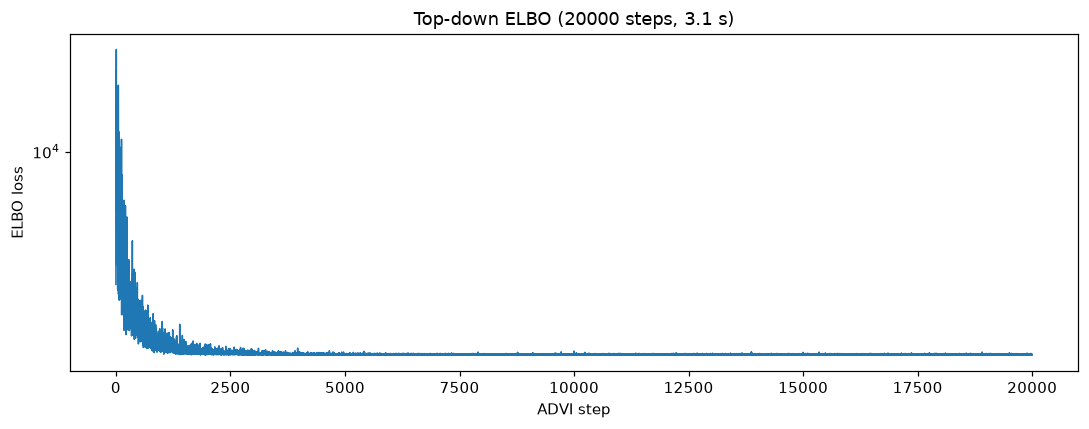

top-down WS-CRPS 0.881, WSPL 0.293


In [6]:
top, top_forecast, top_seconds = fit_and_forecast(TopDownModel(), y_top, cov_top, STEPS["top-down"])
plot_loss(top.losses, f"Top-down ELBO ({STEPS['top-down']} steps, {top_seconds:.1f} s)")
top_draws = reconcile_top_down(top_forecast, panel_sales[:ORIGIN], seed=SEED)
results["top-down"] = (*score(top_draws), top_seconds, top_draws)
print(
    f"top-down WS-CRPS {mean_level_score(results['top-down'][0]):.3f}, "
    f"WSPL {results['top-down'][1]:.3f}"
)

### Bottom-up

Zeros are clamped at `1e-3` before they enter the Gamma likelihood, as in the
kit. The mean and scale heads stay in the model; only the mean is the forecast.


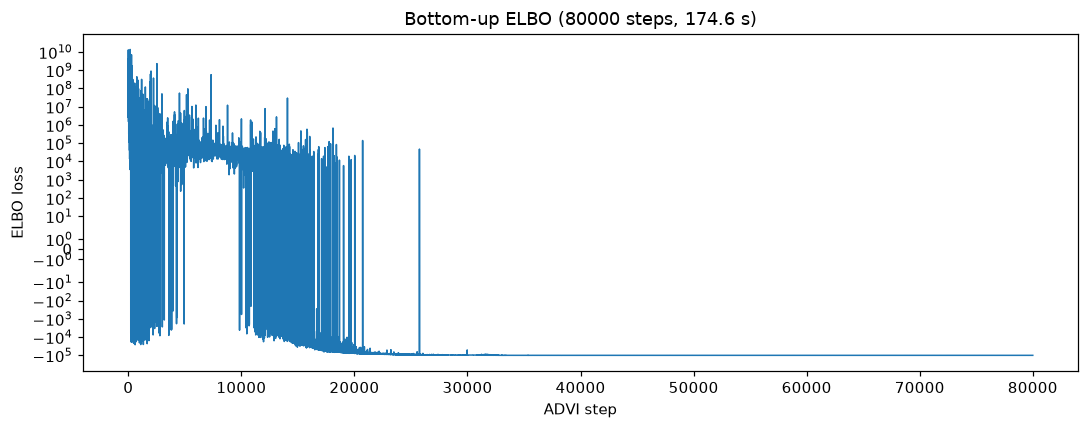

bottom-up WS-CRPS 0.975, WSPL 0.322


In [7]:
bottom_model = BottomUpModel(store_index, dept_index, store_ids, dept_ids)
bottom, bottom_forecast, bottom_seconds = fit_and_forecast(
    bottom_model,
    y_bottom,
    cov_bottom.isel({TIME_DIM: slice(T0, None)}),
    STEPS["bottom-up"],
)
plot_loss(bottom.losses, f"Bottom-up ELBO ({STEPS['bottom-up']} steps, {bottom_seconds:.1f} s)")
bottom_draws = np.asarray(forecast_draws(bottom_forecast).values)
results["bottom-up"] = (*score(bottom_draws), bottom_seconds, bottom_draws)
print(
    f"bottom-up WS-CRPS {mean_level_score(results['bottom-up'][0]):.3f}, "
    f"WSPL {results['bottom-up'][1]:.3f}"
)

### Middle-out

Each store-department series is divided by its own training-window scale. The
forecast is clipped at zero, multiplied back by that scale, and split to the
items of the group.


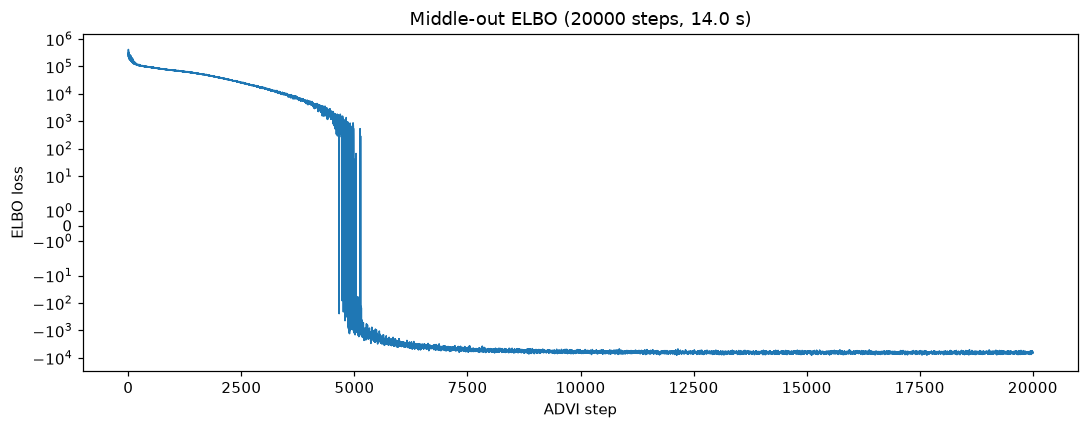

middle-out WS-CRPS 1.674, WSPL 0.673


In [8]:
middle, middle_forecast, middle_seconds = fit_and_forecast(
    MiddleOutModel(), y_mid, cov_mid, STEPS["middle-out"]
)
plot_loss(
    middle.losses,
    f"Middle-out ELBO ({STEPS['middle-out']} steps, {middle_seconds:.1f} s)",
)
middle_draws = reconcile_middle_out(
    middle_forecast,
    panel_sales[:ORIGIN],
    panel.group_index["Level9"],
    scale_mid,
    seed=SEED,
)
results["middle-out"] = (*score(middle_draws), middle_seconds, middle_draws)
print(
    f"middle-out WS-CRPS {mean_level_score(results['middle-out'][0]):.3f}, "
    f"WSPL {results['middle-out'][1]:.3f}"
)

## What the three forecasts say about this panel

The bands are the total of the reconciled bottom draws on this 21-series
subset. They are not competition scores: the subset keeps every hierarchy
level, but it is not the 30,490-series panel, and mean-field ADVI is not
the kit's optimizer. On this subset and seed, top-down has the lowest mean
weighted scaled CRPS, bottom-up is close, and middle-out is worse: its
median sits below the holdout. That ordering is not the kit's full-panel
ranking. The per-level bars are weighted scaled CRPS. Lower is better.


     model  ws_crps     wspl  fit_seconds
  top-down 0.880853 0.293178     3.122813
 bottom-up 0.975380 0.321634   174.611481
middle-out 1.674216 0.672985    14.005132


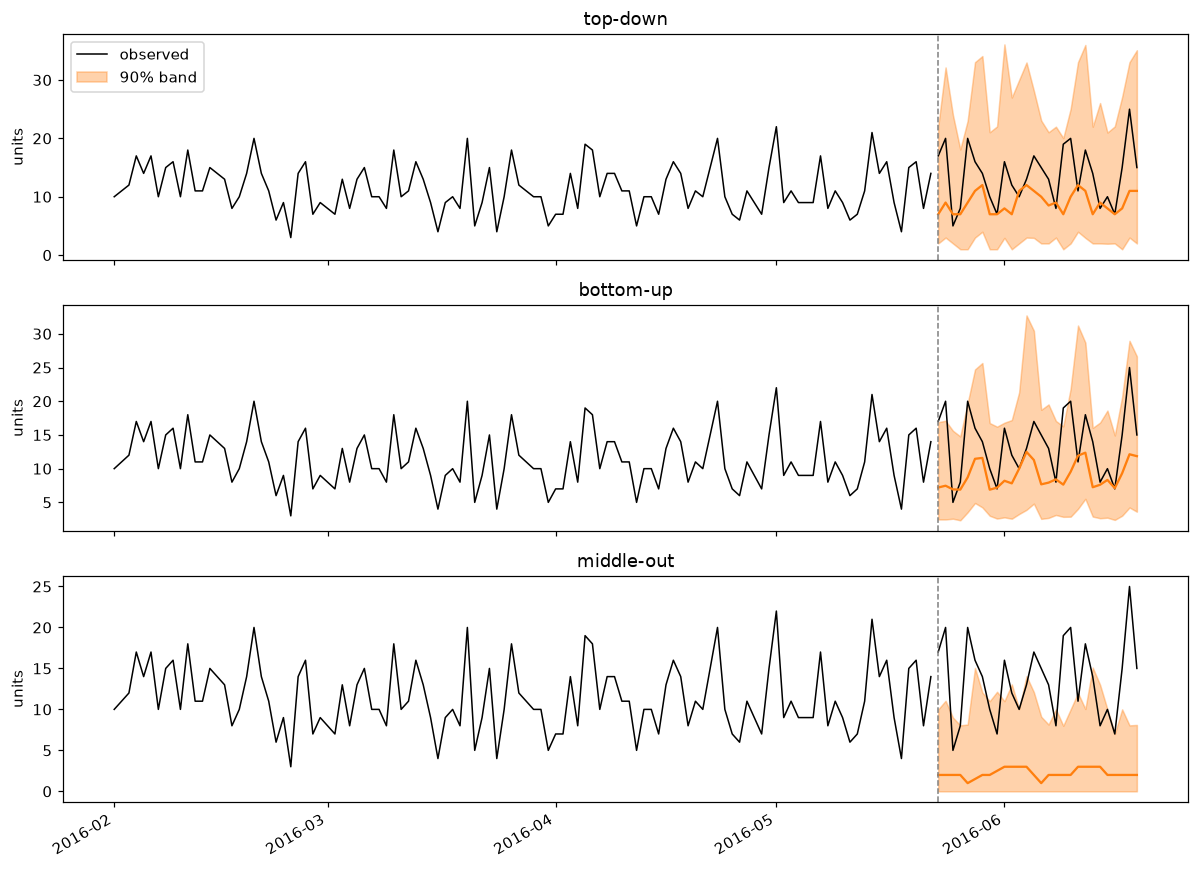

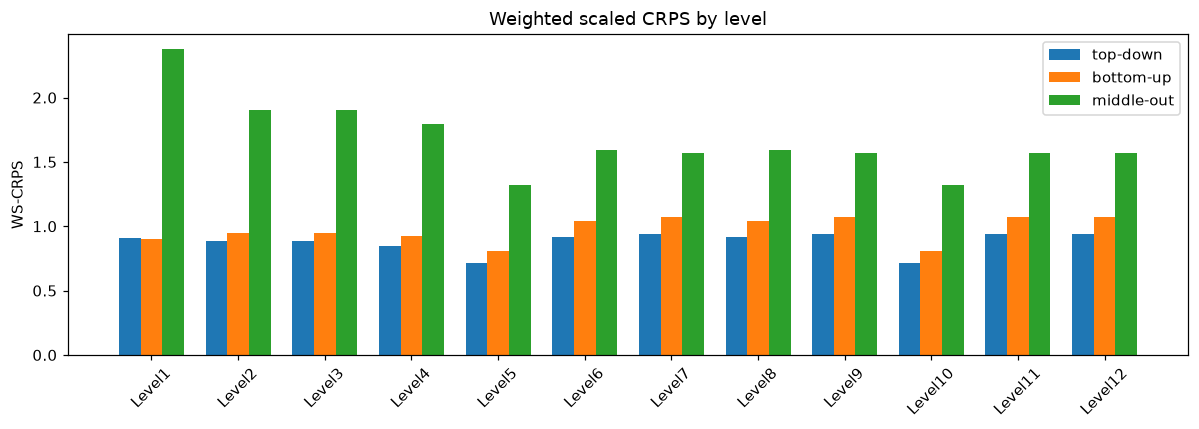

In [9]:
summary = pd.DataFrame(
    [
        {
            "model": name,
            "ws_crps": mean_level_score(scores),
            "wspl": wspl,
            "fit_seconds": elapsed,
        }
        for name, (scores, wspl, elapsed, _) in results.items()
    ]
)
print(summary.to_string(index=False))

history = panel_sales[:ORIGIN].sum(-1)
future_time = cov_top[TIME_DIM].values[ORIGIN:end]
hist_time = cov_top[TIME_DIM].values[max(0, ORIGIN - 16 * 7) : ORIGIN]
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, (name, (_, _, _, draws)) in zip(axes, results.items(), strict=True):
    total = np.asarray(draws).sum(-1)
    low, mid, high = np.quantile(total, [0.05, 0.5, 0.95], axis=0)
    ax.plot(hist_time, history[-len(hist_time) :], color="black", lw=1, label="observed")
    ax.plot(future_time, panel_sales[ORIGIN:end].sum(-1), color="black", lw=1)
    ax.fill_between(future_time, low, high, color="C1", alpha=0.35, label="90% band")
    ax.plot(future_time, mid, color="C1", lw=1.5)
    ax.axvline(future_time[0], color="gray", ls="--", lw=1)
    ax.set(title=name, ylabel="units")
axes[0].legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(LEVELS))
width = 0.25
for k, (name, payload) in enumerate(results.items()):
    scores = payload[0]
    ax.bar(x + (k - 1) * width, [scores[level] for level in LEVELS], width, label=name)
ax.set_xticks(x, list(LEVELS), rotation=45)
ax.set(title="Weighted scaled CRPS by level", ylabel="WS-CRPS")
ax.legend()
fig.tight_layout()
plt.show()

## References

- Pyro team, [Pyro M5 starter kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit).
- Upstream notebook:
  <https://juanitorduz.github.io/numpyro_forecast/docs/examples/m5_forecasting.html>.
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*,
  [hierarchical forecasting](https://otexts.com/fpp3/hierarchical.html).
- M5 competition:
  <https://www.kaggle.com/c/m5-forecasting-uncertainty/overview>.
